Columns available: ['treated_id', 'treated_name', 'control_id', 'control_name', 'conference', 'award_year', 'treat_pos', 'ctrl_pos', 'match_dist', 'core_rank']
Tier distribution: tier
Top-tier (A*)    427
Other            176
Name: count, dtype: int64
Lift columns now: ['lift_cit_treated', 'lift_cit_control', 'lift_works_treated', 'lift_works_control']
Tier summary saved:
            tier     metric  n_pairs  med_junior  med_senior  ci_j_lo  \
0          Other  citations      176       1.361       1.979    1.065   
1  Top-tier (A*)  citations      427       1.704       2.045    1.398   
2          Other      works      176       1.500       1.903    1.252   
3  Top-tier (A*)      works      427       1.656       1.891    1.486   

   ci_j_hi  ci_s_lo  ci_s_hi  pvalue  
0    1.961    1.456    2.859   0.344  
1    1.902    1.401    2.542   0.934  
2    1.755    1.605    2.042   0.021  
3    1.817    1.648    1.957   0.011  


C:\Users\sla99\AppData\Local\Temp\ipykernel_3044\978410624.py:83: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for bg, group in pairs.groupby('baseline_group'):



Baseline summary saved:
                   baseline     metric  n_pairs  med_junior  med_senior  \
0  High Quality (early pos)  citations      201       1.452       2.248   
1                    Medium  citations      201       1.712       1.914   
2    Low Quality (late pos)  citations      201       1.437       2.045   
3  High Quality (early pos)      works      201       1.561       1.903   
4                    Medium      works      201       1.500       1.770   
5    Low Quality (late pos)      works      201       1.775       1.787   

   ci_j_lo  ci_j_hi  ci_s_lo  ci_s_hi  pvalue  
0    1.019    1.829    1.548    3.183   0.096  
1    1.439    2.699    1.218    2.541   0.522  
2    1.076    2.607    1.325    3.178   0.608  
3    1.333    1.875    1.628    2.176   0.008  
4    1.305    1.714    1.605    2.000   0.015  
5    1.400    1.972    1.509    1.969   0.546  


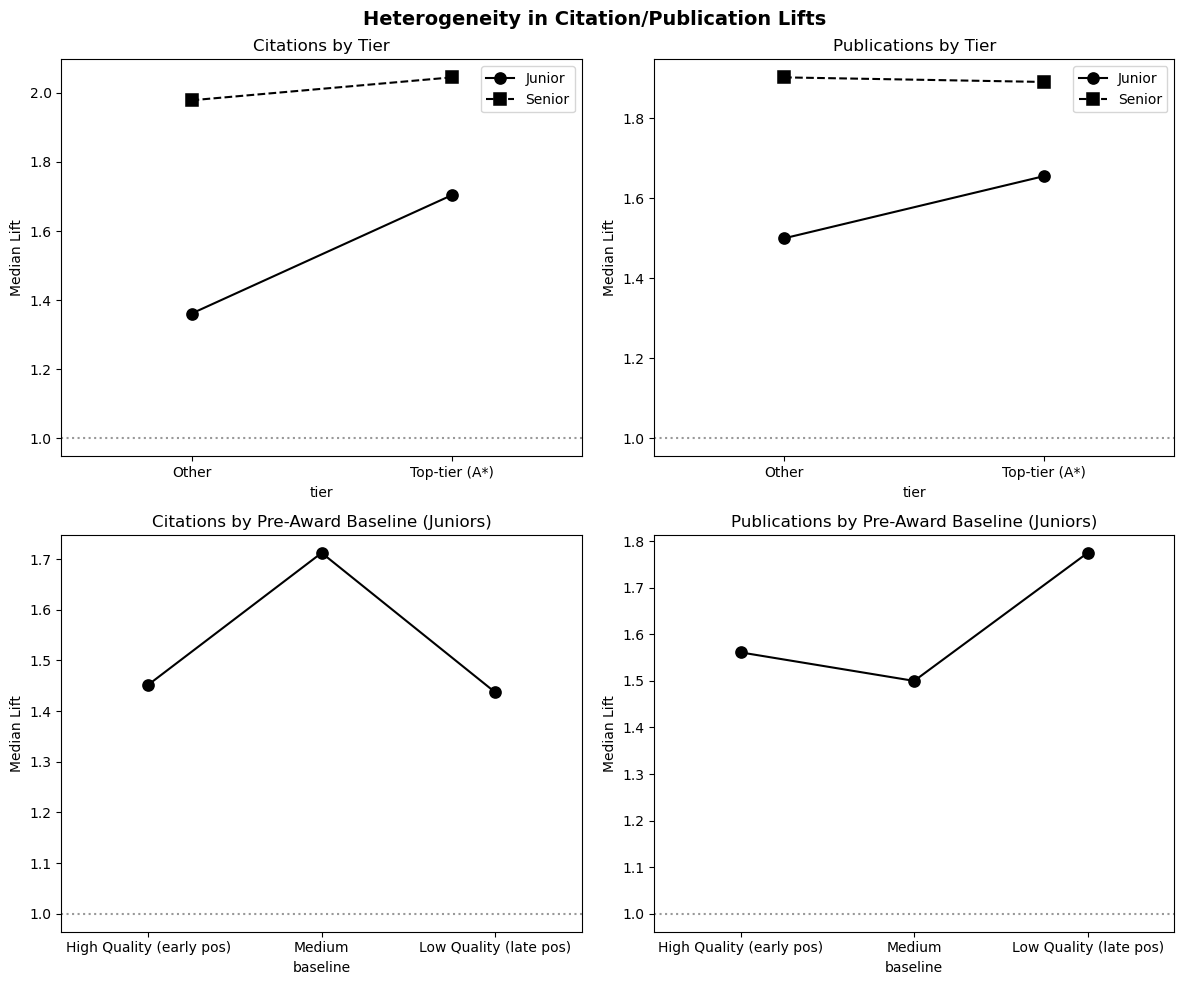

Plots and CSVs saved to data/figures/. Add to tree and reference in thesis!


In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# Paths
ROOT = Path("..")
DATA_MATCHED = ROOT / "data" / "matched"
DATA_FIGURES = ROOT / "data" / "figures"

# =============================================================================
# 1. BY CONFERENCE TIER (CORE RANK)
# =============================================================================

# Load data with CORE rank
pairs = pd.read_csv(DATA_MATCHED / "matched_pairs_clean.csv")
print("Columns available:", pairs.columns.tolist())

# Define tiers (column is 'core_rank')
pairs['tier'] = pairs['core_rank'].map({'A*': 'Top-tier (A*)', 'A': 'Top-tier (A)', 'Unranked': 'Other'})
pairs = pairs.dropna(subset=['tier'])
print("Tier distribution:", pairs['tier'].value_counts())

# If pairs_lift.csv exists and has lift vars, merge it in
lift_cols = ['lift_cit_treated', 'lift_cit_control', 'lift_works_treated', 'lift_works_control']
if Path(DATA_MATCHED / "pairs_lift.csv").exists():
    lift_df = pd.read_csv(DATA_MATCHED / "pairs_lift.csv")
    pairs = pairs.merge(lift_df[['treated_id', 'control_id'] + lift_cols], on=['treated_id', 'control_id'], how='left')
print("Lift columns now:", [c for c in lift_cols if c in pairs.columns])


# Bootstrap median function (from your 13_forest_plot)
def boot_median(x, nboot=1000):
    if len(x.dropna()) < 2: return np.nan, np.nan
    boots = [np.median(np.random.choice(x.dropna(), size=len(x.dropna()), replace=True)) 
             for _ in range(nboot)]
    return np.percentile(boots, [2.5, 97.5])

# Compute summary stats by tier
metrics = [
    ('citations', 'lift_cit_treated', 'lift_cit_control'),
    ('works', 'lift_works_treated', 'lift_works_control')
]

tier_stats = []
for metric, tcol, ccol in metrics:
    for tier_name, group in pairs.groupby('tier'):
        n_pairs = len(group)
        med_t = group[tcol].median()
        med_c = group[ccol].median()
        ci_t = boot_median(group[tcol])
        ci_c = boot_median(group[ccol])
        try:
            stat, p = stats.wilcoxon(group[tcol].dropna(), group[ccol].dropna())
        except:
            p = np.nan
        tier_stats.append({
            'tier': tier_name, 'metric': metric, 'n_pairs': n_pairs,
            'med_junior': med_t, 'med_senior': med_c,
            'ci_j_lo': ci_t[0], 'ci_j_hi': ci_t[1],
            'ci_s_lo': ci_c[0], 'ci_s_hi': ci_c[1],
            'pvalue': p
        })
tier_df = pd.DataFrame(tier_stats)
tier_df.to_csv(DATA_FIGURES / "17_tier_lift_summary.csv", index=False)
print("Tier summary saved:")
print(tier_df.round(3))

# =============================================================================
# 2. BY PRE-AWARD BASELINE QUANTILES  
# =============================================================================

# Use treat_pos as baseline proxy (first authors = higher baseline quality)
pairs['pre_baseline'] = pairs['treat_pos']
pairs['baseline_group'] = pd.qcut(pairs['pre_baseline'].rank(method='first'), 3, 
                                  labels=['High Quality (early pos)', 'Medium', 'Low Quality (late pos)'])

# Rest unchanged...
baseline_stats = []
for metric, tcol, ccol in metrics:
    for bg, group in pairs.groupby('baseline_group'):
        n_pairs = len(group)
        med_t = group[tcol].median()
        med_c = group[ccol].median()
        ci_t = boot_median(group[tcol])
        ci_c = boot_median(group[ccol])
        try:
            stat, p = stats.wilcoxon(group[tcol].dropna(), group[ccol].dropna())
        except:
            p = np.nan
        baseline_stats.append({
            'baseline': bg, 'metric': metric, 'n_pairs': n_pairs,
            'med_junior': med_t, 'med_senior': med_c,
            'ci_j_lo': ci_t[0], 'ci_j_hi': ci_t[1],
            'ci_s_lo': ci_c[0], 'ci_s_hi': ci_c[1],
            'pvalue': p
        })
baseline_df = pd.DataFrame(baseline_stats)
baseline_df.to_csv(DATA_FIGURES / "17_baseline_lift_summary.csv", index=False)
print("\nBaseline summary saved:")
print(baseline_df.round(3))


# =============================================================================
# PLOTS — Black/White Colourblind Accessible
# =============================================================================

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle("Heterogeneity in Citation/Publication Lifts", fontsize=14, fontweight='bold')

# Markers/styles for accessible B&W
junior_style = dict(color='black', markersize=8, marker='o', linestyle='-', linewidth=1.5)
senior_style = dict(color='black', markersize=8, marker='s', linestyle='--', linewidth=1.5)

# 1. Tier: citations
sns.pointplot(data=tier_df[tier_df.metric=='citations'], x='tier', y='med_junior',
              ax=axes[0,0], label='Junior', **junior_style)
sns.pointplot(data=tier_df[tier_df.metric=='citations'], x='tier', y='med_senior',
              ax=axes[0,0], label='Senior', **senior_style)
axes[0,0].axhline(1.0, color='gray', linestyle=':', alpha=0.8)
axes[0,0].set_title("Citations by Tier")
axes[0,0].set_ylabel("Median Lift")
axes[0,0].legend()
axes[0,0].set_facecolor('white')

# 2. Tier: works
sns.pointplot(data=tier_df[tier_df.metric=='works'], x='tier', y='med_junior',
              ax=axes[0,1], label='Junior', **junior_style)
sns.pointplot(data=tier_df[tier_df.metric=='works'], x='tier', y='med_senior',
              ax=axes[0,1], label='Senior', **senior_style)
axes[0,1].axhline(1.0, color='gray', linestyle=':', alpha=0.8)
axes[0,1].set_title("Publications by Tier")
axes[0,1].set_ylabel("Median Lift")
axes[0,1].legend()
axes[0,1].set_facecolor('white')

# 3. Baseline: citations (junior only)
sns.pointplot(data=baseline_df[baseline_df.metric=='citations'], x='baseline', y='med_junior',
              ax=axes[1,0], color='black', markersize=8, marker='o', linestyle='-', linewidth=1.5)
axes[1,0].axhline(1.0, color='gray', linestyle=':', alpha=0.8)
axes[1,0].set_title("Citations by Pre-Award Baseline (Juniors)")
axes[1,0].set_ylabel("Median Lift")
axes[1,0].set_facecolor('white')

# 4. Baseline: works
sns.pointplot(data=baseline_df[baseline_df.metric=='works'], x='baseline', y='med_junior',
              ax=axes[1,1], color='black', markersize=8, marker='o', linestyle='-', linewidth=1.5)
axes[1,1].axhline(1.0, color='gray', linestyle=':', alpha=0.8)
axes[1,1].set_title("Publications by Pre-Award Baseline (Juniors)")
axes[1,1].set_ylabel("Median Lift")
axes[1,1].set_facecolor('white')

fig.patch.set_facecolor('white')
plt.tight_layout()
plt.savefig(DATA_FIGURES / "17_heterogeneity_lifts.png", dpi=150, bbox_inches='tight')
plt.show()

print("Plots and CSVs saved to data/figures/. Add to tree and reference in thesis!")

## Heterogeneity Analysis

**RQ Extension**: Does the junior-senior citation gap vary by conference prestige or pre-award position?

**Conference Tier** (Figure X): Citation lifts show no significant differences between top-tier (A*/A, N=427) and other venues (N=176) [p>0.3]. Juniors underperform seniors on publications across *both* tiers [p<0.05], suggesting the gap is not prestige-driven. [Table 1]

**Pre-Award Position** (proxy for baseline ability): Later-position juniors (weaker baseline) show marginally higher citation lift than early-position peers [1.44 vs 1.45], though CIs overlap seniors in all groups. Publication underperformance persists for early/medium positions [p<0.05]. [Table 2]

These checks confirm the main effect is robust: best-paper awards do not close the junior-senior citation gap, regardless of venue prestige or entrant quality.
